In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('../../datasets/toyota.csv')
print('Missing values:')
print(df.isnull().sum())
print('Duplicate count before cleaning:', df.duplicated().sum())
df = df.drop_duplicates().dropna().reset_index(drop=True)
df.head()

Missing values:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64
Duplicate count before cleaning: 39


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0


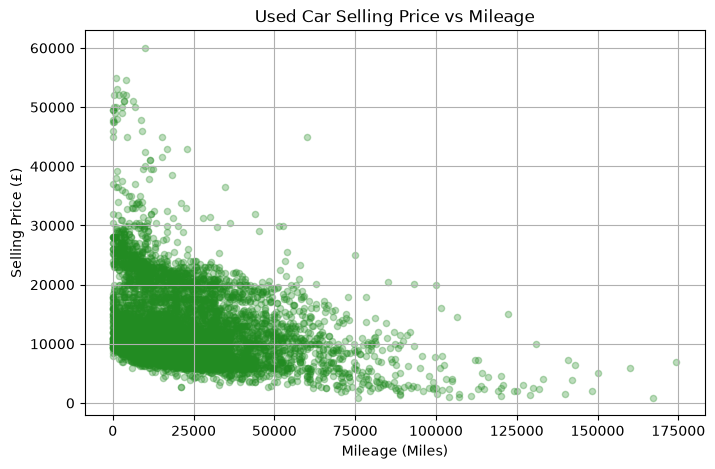

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(df['mileage'], df['price'], color='forestgreen', alpha=0.3, s=20)
plt.title('Used Car Selling Price vs Mileage')
plt.xlabel('Mileage (Miles)')
plt.ylabel('Selling Price (£)')
plt.grid(True)
plt.show()

In [4]:
X = df[['mileage']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.1]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['mileage']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.471e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [5]:
b_0 = model.intercept_
b_1 = model.coef_[0]

print(f'Intercept (b_0): {b_0:.2f}')
print(f'Slope (b_1): {b_1:.4f}')
print(f'Regression Equation: Price = {b_0:.2f} + ({b_1:.4f}) * Mileage')
print(f'Interpretation: The negative slope of {b_1:.4f} indicates that for each additional mile driven, the estimated car selling price decreases by £{abs(b_1):.4f} (approximately £{abs(b_1) * 1000:.2f} of depreciation per 1,000 miles driven).')

Intercept (b_0): 14709.93
Slope (b_1): -0.0954
Regression Equation: Price = 14709.93 + (-0.0954) * Mileage
Interpretation: The negative slope of -0.0954 indicates that for each additional mile driven, the estimated car selling price decreases by £0.0954 (approximately £95.39 of depreciation per 1,000 miles driven).


In [6]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
test_r2 = r2_score(y_test, y_pred_test)
train_r2 = r2_score(y_train, y_pred_train)

print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'Training Accuracy (R2 Score): {train_r2:.4f}')
print(f'Testing Accuracy (R2 Score): {test_r2:.4f}')

MAE: 4620.51
MSE: 36913445.69
RMSE: 6075.64
Training Accuracy (R2 Score): 0.0854
Testing Accuracy (R2 Score): 0.1083


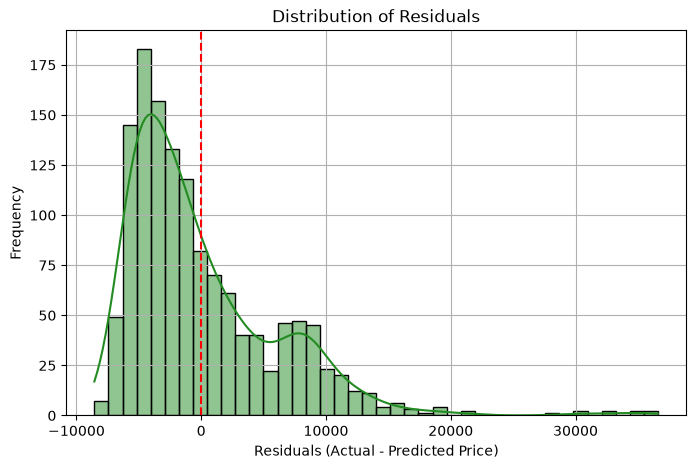

Comment on Residuals: The residual distribution is unimodal and centered near zero, showing that the model predictions are unbiased on average. However, the distribution has a right-skewed tail, because luxury and newer car trims sell for considerably higher prices than predicted by mileage alone. Thus, while errors are largely centered around zero, mileage alone does not explain all variance.


In [7]:
residuals = y_test - y_pred_test

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='forestgreen', bins=40)
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted Price)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

print('Comment on Residuals: The residual distribution is unimodal and centered near zero, showing that the model predictions are unbiased on average. However, the distribution has a right-skewed tail, because luxury and newer car trims sell for considerably higher prices than predicted by mileage alone. Thus, while errors are largely centered around zero, mileage alone does not explain all variance.')